In [1]:
%pip install pandas requests textblob wordcloud newsapi haversine tabulate
#TODO: VSCode requires the use of % instead of !. This should be changed back before submission.
#CHANGE: Added Haversine for my portion. Haversine is a package used to measure distance between coordinates.
import requests #downloads zip file from webpage
import pandas as pd
import matplotlib.pyplot as plt
import zipfile #extracts csv from zip
import io #allows treat downloaded data as a file object
import seaborn as sns
import time#allows for the program to pause to avoid API rate limits
from textblob import TextBlob # will be used to analyse news from the internet
#TODO: This line does not work in VSCode, might work in Colab. Should check before submitting.
#New code from  https://github.com/mattlisiv/newsapi-python/issues/5#issuecomment-448281100
#from newsapi import NewsApiClient # will be used to extract latests articles
from newsapi.newsapi_client import NewsApiClient # will be used to extract latests articles (Replaces previous line)
from wordcloud import WordCloud# to create a word cloud of words mostly used in the articles
from haversine import haversine, Unit #to measure distance between Capital Bikeshare stations and public transit stations
from tabulate import tabulate #Used to print table


Note: you may need to restart the kernel to use updated packages.


In [2]:
web = [#'https://s3.amazonaws.com/capitalbikeshare-data/2010-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2011-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2012-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2013-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2014-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2015-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2016-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2017-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201801-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201802-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201803-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201804-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201805-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201806-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201807-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201808-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201809-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201810-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201811-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201812-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201901-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201902-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201903-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201904-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201905-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201906-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201907-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201908-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201907-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201908-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201909-capitalbikeshare-tripdata.zip',
      #'https://s3.amazonaws.com/capitalbikeshare-data/201910-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201911-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201912-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/202001-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/202002-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/202003-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202005-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202006-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202007-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202008-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202009-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202010-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202011-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202012-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202101-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202102-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202103-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202104-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202105-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202106-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202107-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202108-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202109-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202110-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202111-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202112-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202201-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202202-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202203-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202204-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202205-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202206-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202207-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202208-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202209-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202210-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202211-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202212-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202301-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202302-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202303-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202304-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202305-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202306-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202307-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202308-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202309-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202310-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202311-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202312-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202401-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202402-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202403-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202404-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202405-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202406-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202407-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202408-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202409-capitalbikeshare-tripdata.zip']
#commented first files that didn't have the same set of columns
df_list = [] #adding each file as a dataframe to a list

In [3]:
#This line might take a while, you're downloading 16million lines of data
#Just let the program do it's thing and ensure you have sufficient memory available
for url in web:
    response = requests.get(url) #downloaded zip file from web
    if response.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file: #extracting the data
            for filename in zip_file.namelist():
                #if filename.endwith('.csv'):
                with zip_file.open(filename) as f:
                    df_1 = pd.read_csv(f, encoding='ISO-8859-1', low_memory=False) # there was some error in the columns (missmatch of value types)
                    df_list.append(df_1)
    else:
        print(f'Failed to download the ZIP file from {url} . Status code ', response.status_code)
df = pd.concat(df_list, ignore_index = True)
print(df)

                   ride_id  rideable_type               started_at  \
0         946D42AD89539210    docked_bike      2020-05-30 17:25:29   
1         CC46FAAB662B8613    docked_bike      2020-05-09 14:42:04   
2         72F00B2FB833D6ED    docked_bike      2020-05-24 17:27:19   
3         4DFBE6AED989DF35    docked_bike      2020-05-27 15:29:52   
4         1AAFE6B4331AB9DF    docked_bike      2020-05-31 14:06:03   
...                    ...            ...                      ...   
16751517  4C2859F401A89BE4  electric_bike  2024-09-16 17:23:10.553   
16751518  36C4ADE33349BF44  electric_bike  2024-09-16 08:59:39.257   
16751519  F01550D1A53887E1  electric_bike  2024-09-16 06:42:03.153   
16751520  5D3E7F1E248D4781  electric_bike  2024-09-16 14:56:28.251   
16751521  43524A3F14B4411D  electric_bike  2024-09-16 15:03:28.717   

                         ended_at  \
0             2020-05-31 18:25:22   
1             2020-05-09 15:06:33   
2             2020-05-24 17:43:51   
3          

In [4]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,946D42AD89539210,docked_bike,2020-05-30 17:25:29,2020-05-31 18:25:22,Anacostia Library,31804,11th & H St NE,31614.0,38.865784,-76.978400,38.899983,-76.991383,casual,NaN,NaN,NaN
1,CC46FAAB662B8613,docked_bike,2020-05-09 14:42:04,2020-05-09 15:06:33,10th & E St NW,31256,21st St & Constitution Ave NW,31261.0,38.895914,-77.026064,38.892459,-77.046567,member,NaN,NaN,NaN
2,72F00B2FB833D6ED,docked_bike,2020-05-24 17:27:19,2020-05-24 17:43:51,Connecticut Ave & Newark St NW / Cleveland Park,31305,12th & U St NW,31268.0,38.934267,-77.057979,38.916787,-77.028139,member,NaN,NaN,NaN
3,4DFBE6AED989DF35,docked_bike,2020-05-27 15:29:52,2020-05-27 15:47:13,Connecticut Ave & Newark St NW / Cleveland Park,31305,14th & Belmont St NW,31119.0,38.934267,-77.057979,38.921074,-77.031887,casual,NaN,NaN,NaN
4,1AAFE6B4331AB9DF,docked_bike,2020-05-31 14:06:03,2020-05-31 14:30:30,Georgia Ave & Morton St NW,31419,17th & K St NW,31213.0,38.932128,-77.023500,38.902760,-77.038630,casual,NaN,NaN,NaN


In [5]:
df['Unnamed: 0'].describe()

count                   9
unique                  1
top       #mËx.Oé TìG
freq                    9
Name: Unnamed: 0, dtype: object

In [6]:
#idk what those last columns are about, probably can just delete
df = df.drop(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2'], axis=1)

In [7]:
#Convert 'started_at' and 'ended_at' to datetime
df['started_at'] = pd.to_datetime(df['started_at'], format='ISO8601')
df['ended_at'] = pd.to_datetime(df['ended_at'], format='ISO8601')

#Calculate additional columns
#TODO: Check if anyone is using these columns before we submit. If no one is using them, removing would be best
#for memory savings
df['Time Start'] = df['started_at'].dt.time
df['Time End'] = df['ended_at'].dt.time
df['Year'] = df['started_at'].dt.year
df['Month'] = df['started_at'].dt.month 
df['Day Started'] = df['started_at'].dt.day_name()

#Calculate ride length
df['Ride Length'] = df['ended_at'] - df['started_at']
df['Ride Length_min'] = pd.to_timedelta(df['Ride Length']).dt.seconds/60

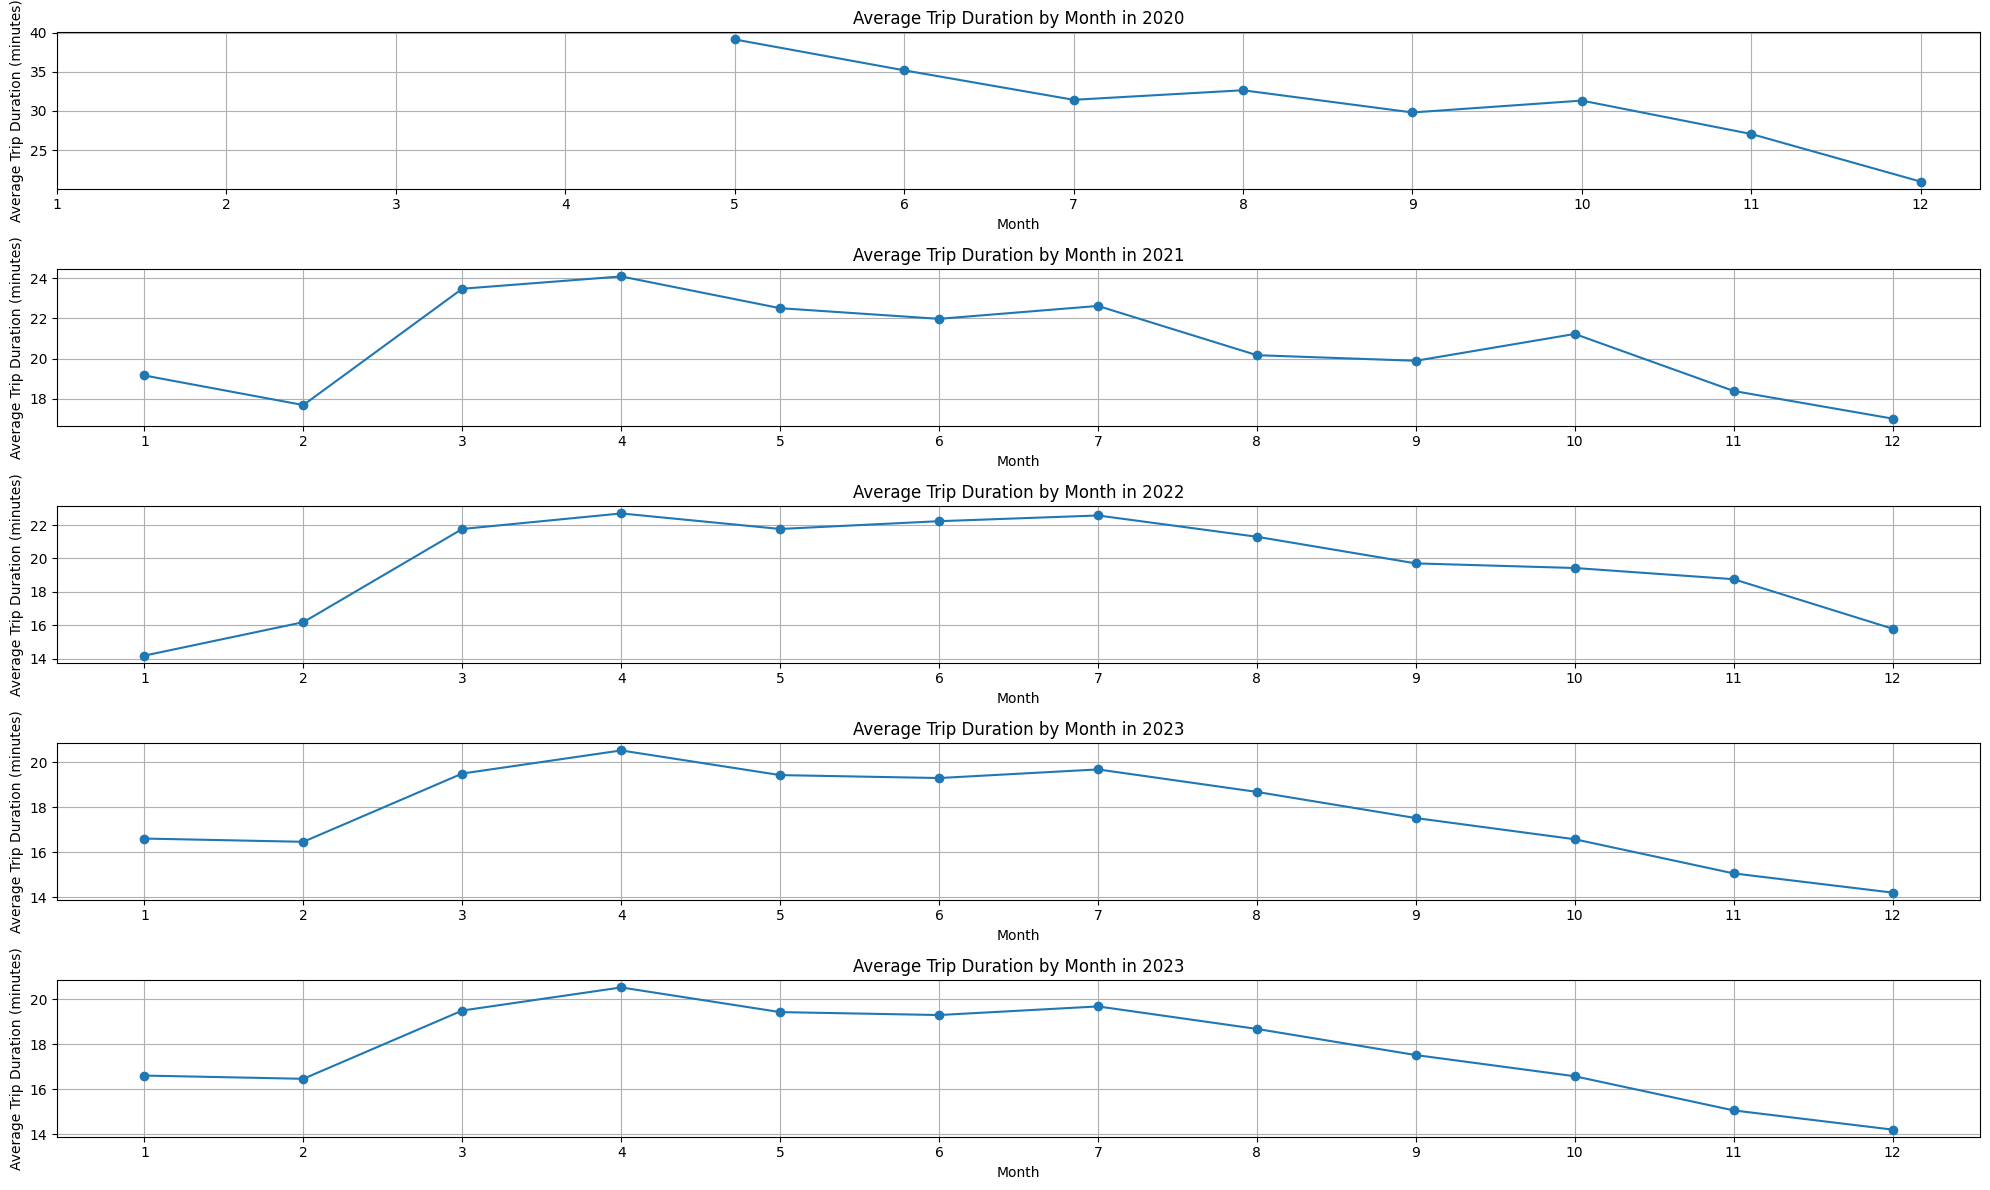

In [14]:
def plot_average_trip_length(df, year):
    #Plots average trip duration by month in a given year
    #Input: df - the dataframe to analyze
    #Input: The year to analyze
    #Output: a graph showing average trip length for each month in a year

    #Filter for the specified year
    df_year = df[df['Year'] == year]

    #Calculate average trip duration per month
    monthly_average_duration = df_year.groupby('Month')['Ride Length_min'].mean()

    #Plot results
    plt.plot(monthly_average_duration.index, monthly_average_duration.values, marker='o')
    plt.xlabel('Month')
    plt.ylabel('Average Trip Duration (minutes)')
    plt.title(f'Average Trip Duration by Month in {year}')
    plt.xticks(range(1, 13))
    plt.grid(True)

#Create a 5 * 1 figure to hold smaller plots
plt.figure(figsize=(20, 12))

#Plot for 2020
plt.subplot(5, 1, 1)
plot_average_trip_length(df, 2020)

#Plot for 2021
plt.subplot(5, 1, 2)
plot_average_trip_length(df, 2021)

#Plot for 2022
plt.subplot(5, 1, 3)
plot_average_trip_length(df, 2022)

#Plot for 2023
plt.subplot(5, 1, 4)
plot_average_trip_length(df, 2023)

#Plot for 2024
plt.subplot(5, 1, 5)
plot_average_trip_length(df, 2023)

plt.tight_layout()
plt.show()

Average trip length seems to consistently peak in April

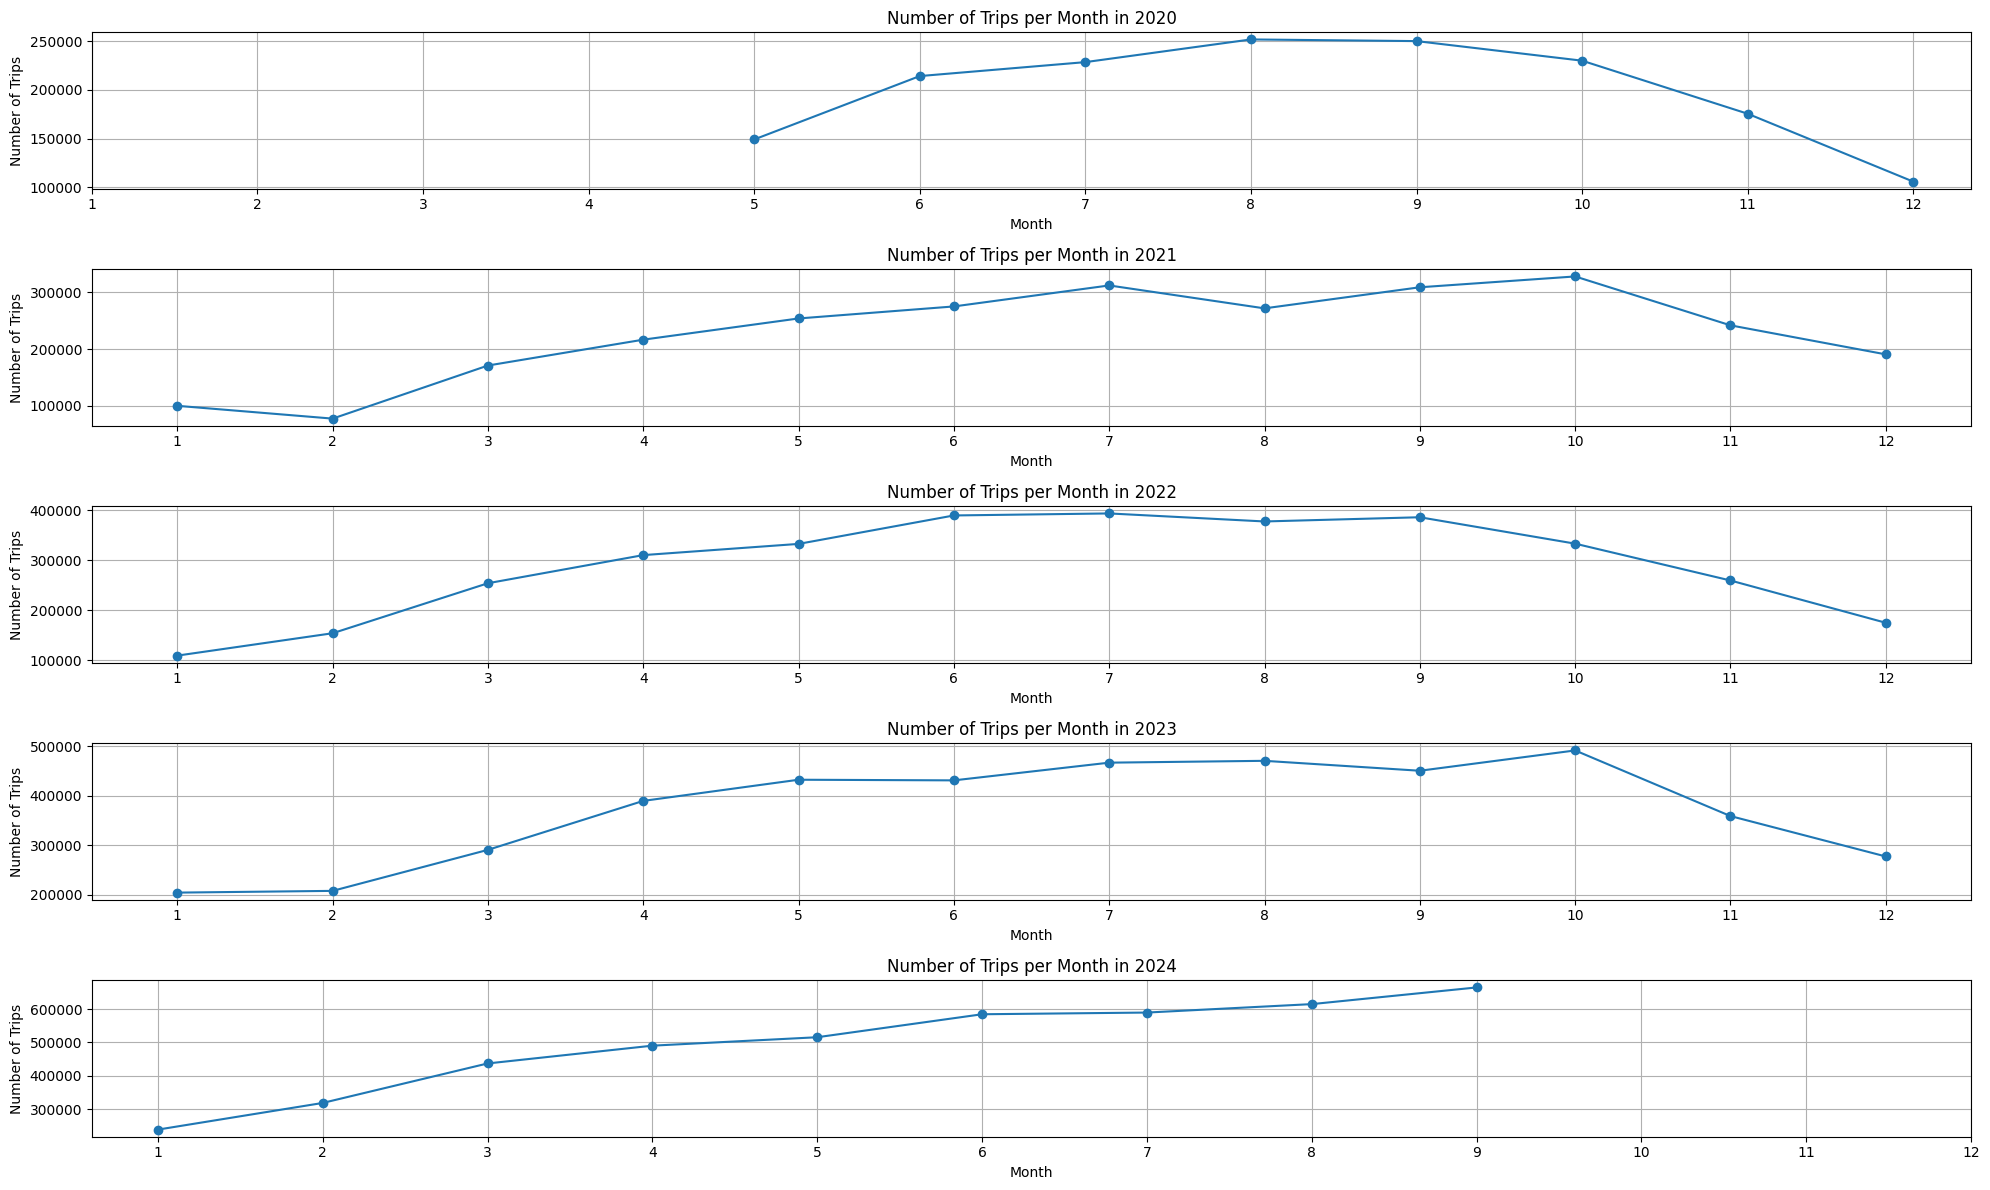

In [15]:
def plot_monthly_trips(df, year):
    #Plots number of trips taken each month in a given year
    #Input: df - dataframe to analyze
    #Input: year - year to analyze
    #Output: A graph with number of monthly trips in given year

    #Filter by given year
    df_year = df[df['Year'] == year]
    
    #Get months of year
    df_year.loc[:, 'Month'] = df_year['started_at'].dt.month
    
    
    #Count trips in each month
    monthly_trips = df_year.groupby('Month').size()
    
    #Plot results
    plt.plot(monthly_trips.index, monthly_trips.values, marker='o')
    plt.xlabel('Month')
    plt.ylabel('Number of Trips')
    plt.title(f'Number of Trips per Month in {year}')
    plt.xticks(range(1, 13))
    plt.grid(True)

#Create a 5 * 1 figure to hold smaller grids
plt.figure(figsize=(20, 12))

#Plot for 2020
plt.subplot(5, 1, 1)
plot_monthly_trips(df, 2020)

#Plot for 2021
plt.subplot(5, 1, 2)
plot_monthly_trips(df, 2021)

#Plot for 2022
plt.subplot(5, 1, 3)
plot_monthly_trips(df, 2022)

#Plot for 2023
plt.subplot(5, 1, 4)
plot_monthly_trips(df, 2023)

#Plot for 2023
plt.subplot(5, 1, 5)
plot_monthly_trips(df, 2024)

plt.tight_layout()
plt.show()

Observation: Ridership is consistently increasing year over year. There is a steady drop off in ridership during Winter, with a somewhat consistent peak around Summer time.

<h3>How does usage change throughout the system?</h3>

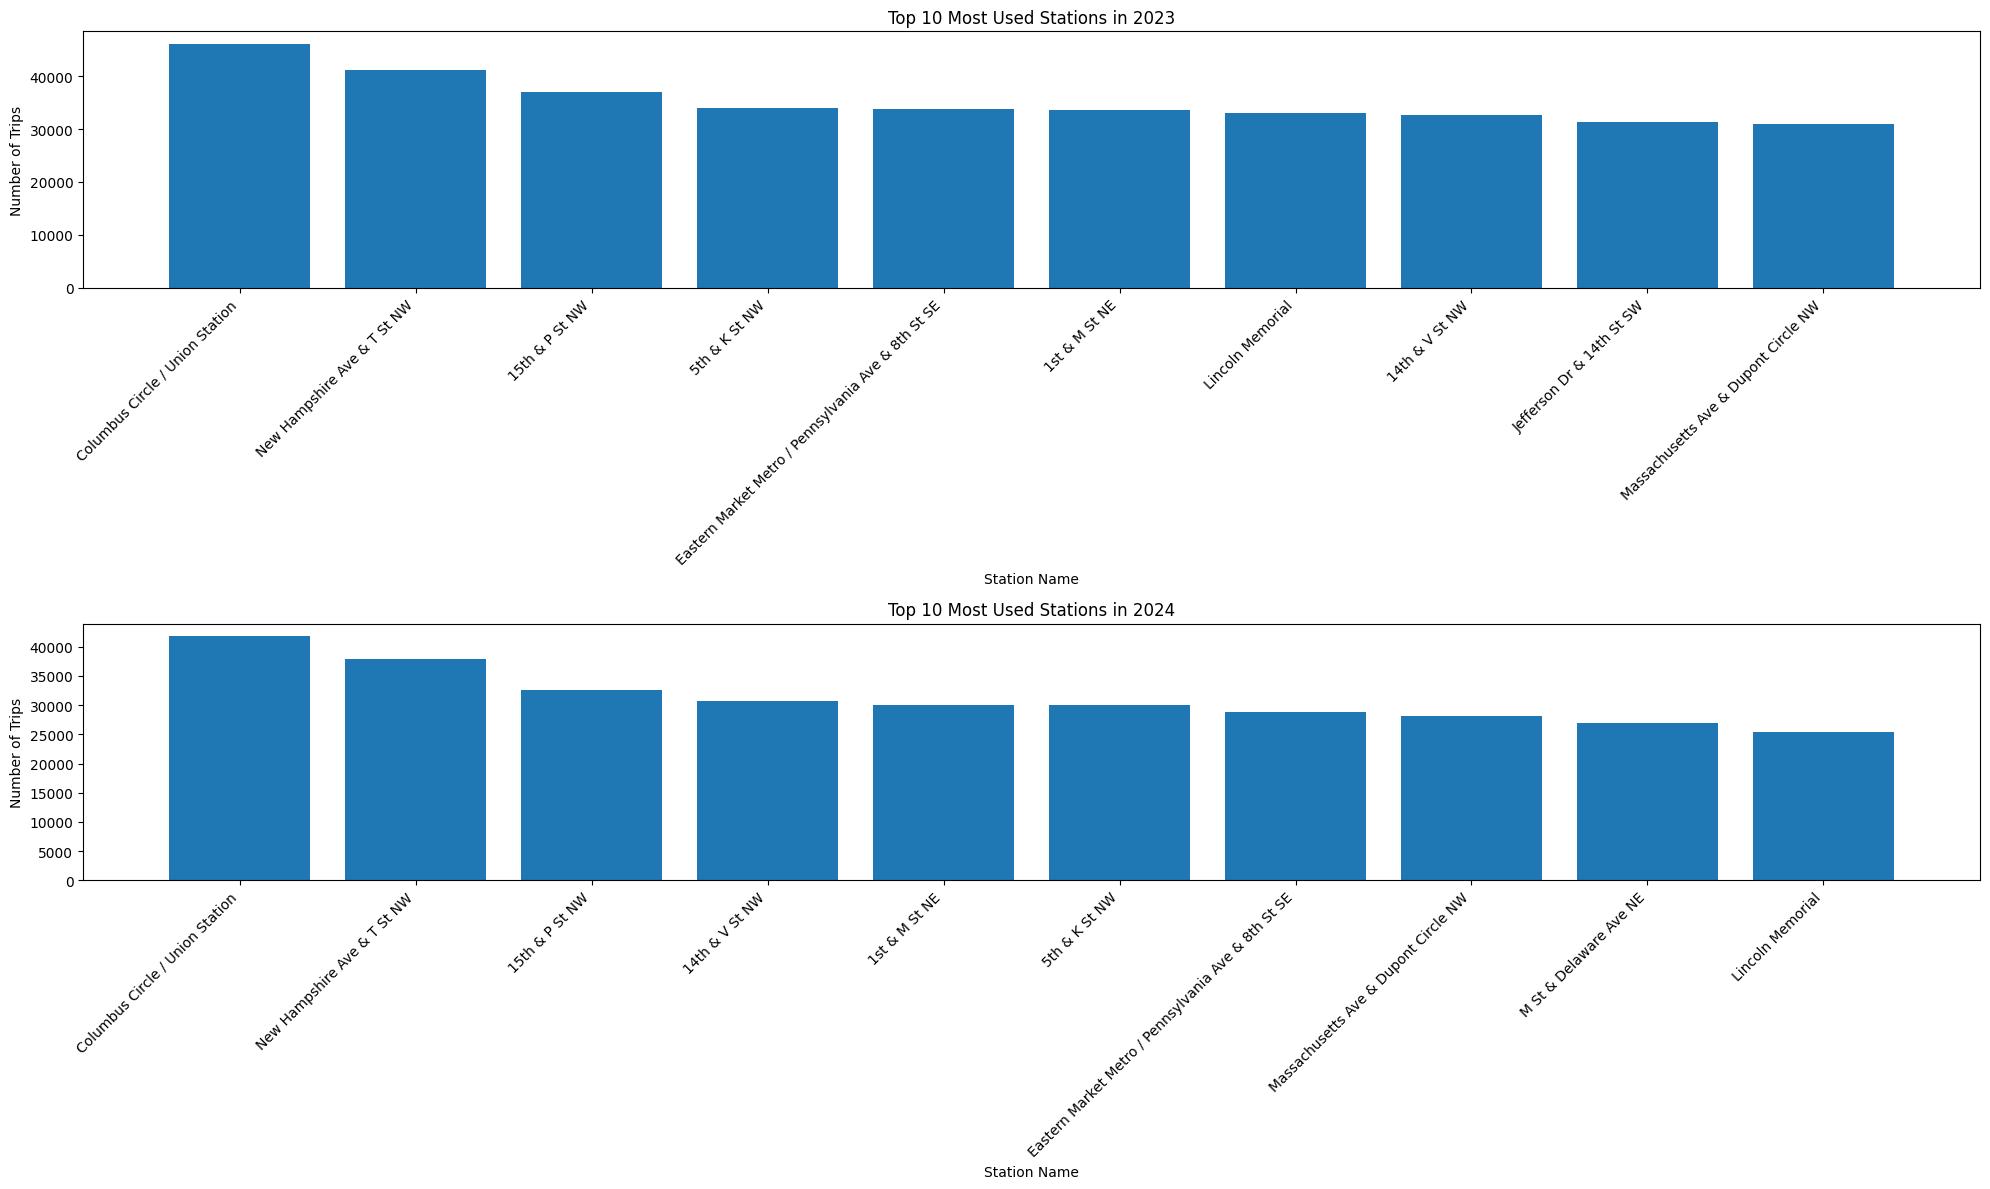

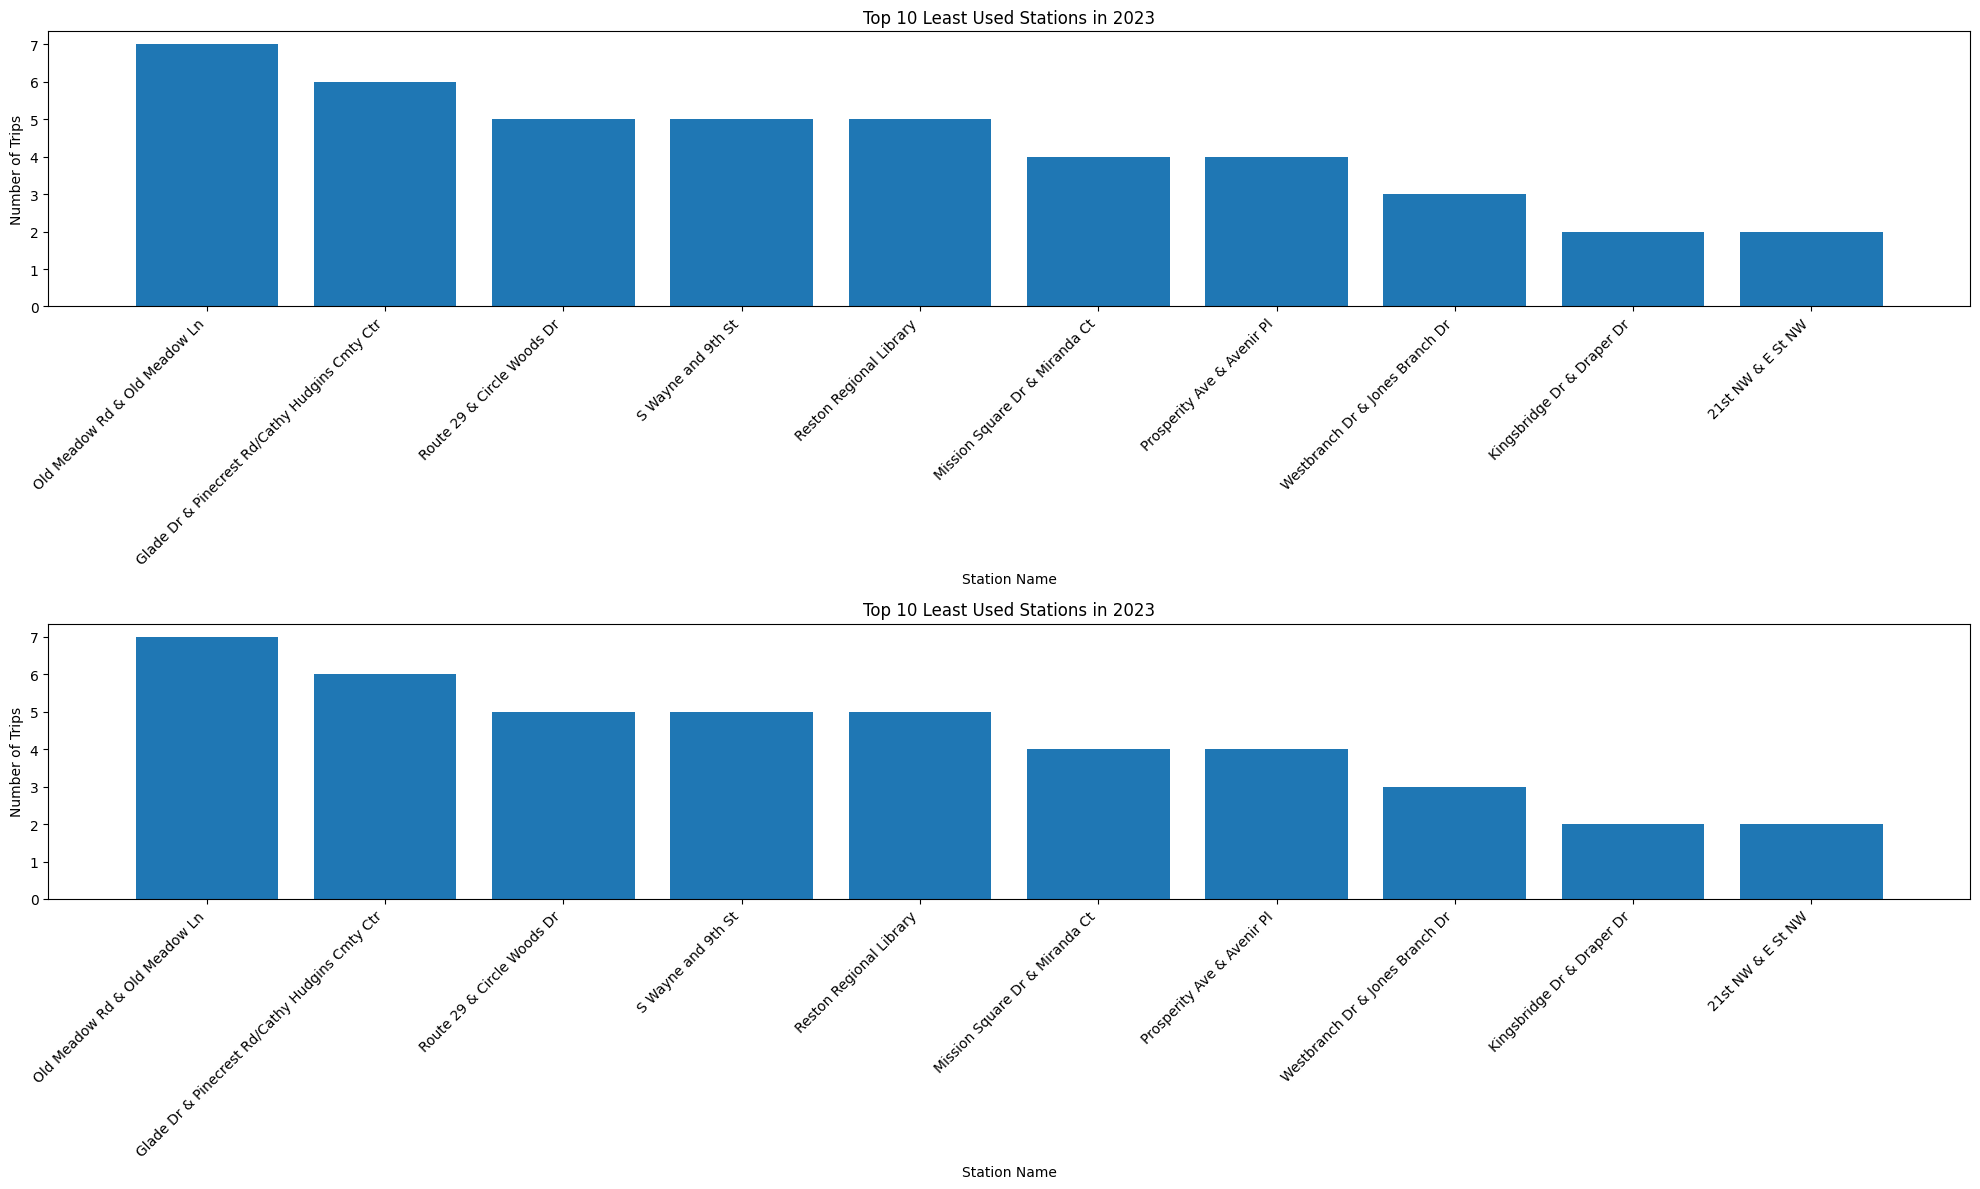

In [16]:
#OBSERVATION: All of the most used stations are in DC
#NOTE/Lesson: This cell was a bit of a challenge because I initally placed all of my code in one/two
#methods, and as a result, graphs appeared when all I wanted was a return value.
#To preserve readability, I'm only using the most used stations for 2 years rather than 2020-2024

def get_notable_stations(df, year, least_used = False):
    #Gets the head or tail of stations in a dataframe. This method is only intended to be called by other
    #(specifically, the proceeding 2) methods
    #Input - df: dataframe to analyze
    #Input - year: year to analyze
    #Input - least_used: True if least used stations are desired. Default behavior is false and returns most
    #used stations.

    #Specify the year
    df_year = df[df['Year'] == year]

    #NOTE: Even though only start stations are being counted, it doens't really matter for overall findings. The top 10
    #most/least commonly used start stations are the same as the top 10 most/least commonly used end stations, with
    #the only difference being position inside the top 10
    #Count the frequency of each station
    station_counts = df_year['start_station_name'].value_counts()

    #Return the top 10 most or least used stations
    return (station_counts.head(10) if least_used is False else station_counts.tail(10))

def plot_station_usage(year, least_used = False):
    #Assembles plots of station usage. Calls the get_notable_stations method to obtain the
    #stations that should be analyzed
    #Input - year: year to plot
    #Input - least_used: True if least used stations are desired. Default behavior is false and plots most
    #used stations.

    #Obtain stations to analyze
    notable_stations = get_notable_stations(df, year, least_used)
    plt.bar(notable_stations.index, notable_stations.values)
    plt.xlabel('Station Name')
    plt.ylabel('Number of Trips')
    plt.title(f'Top 10 {("Most" if least_used is False else "Least")} Used Stations in {year}')
    plt.xticks(rotation=45, ha='right') #Needed for readability

#Create a 2 * 1 figure to hold smaller grids
plt.figure(figsize=(20, 12))

#Plot for 2023
plt.subplot(2, 1, 1)
plot_station_usage(2023)

#Plot for 2024
plt.subplot(2, 1, 2)
plot_station_usage(2024)

plt.tight_layout() #Needed for readability
plt.show()

#Plot the least used stations of 2023 and 2024
#OBSERVATION: Many of these (if not all) are outside of DC

#Create a 2 * 1 figure to hold smaller grids
plt.figure(figsize=(20, 12))

#Plot for 2023
plt.subplot(2, 1, 1)
plot_station_usage(2023, True)

#Plot for 2024
plt.subplot(2, 1, 2)
plot_station_usage(2023, True)


plt.tight_layout()
plt.show()

Though their positions change, the top 10 most used stations for both 2023 and 2024 were

Columbus Circle / Union Station
New Hampshire Ave & T St Nw
15th & P St NW
14th & V St Nw
1st & M St NE
5th & K St NW
Eastern Market Metro / Pennsylvania Ave & 8th St SE
Massachussetts Ave & Dupont Circle NW
M St & Delaware Ave NE

In [17]:
"""#Plot the least used stations of 2023 and 2024
#OBSERVATION: Many of these (if not all) are outside of DC

#Create a 2 * 1 figure to hold smaller grids
plt.figure(figsize=(20, 12))

#Plot for 2023
plt.subplot(2, 1, 1)
plot_station_usage(2023, True)

#Plot for 2024
plt.subplot(2, 1, 2)
plot_station_usage(2023, True)


plt.tight_layout()
plt.show()"""

'#Plot the least used stations of 2023 and 2024\n#OBSERVATION: Many of these (if not all) are outside of DC\n\n#Create a 2 * 1 figure to hold smaller grids\nplt.figure(figsize=(20, 12))\n\n#Plot for 2023\nplt.subplot(2, 1, 1)\nplot_station_usage(2023, True)\n\n#Plot for 2024\nplt.subplot(2, 1, 2)\nplot_station_usage(2023, True)\n\n\nplt.tight_layout()\nplt.show()'

In [18]:
#NOTE: There's a question somewhere asking what I would do if I had another month to work.
#I would incorporate the WalkScore API, but unfortunately I did not know that I had to request
#access until it was too late
apikey = "f4ec5f6332be467aa220d3075093b0e6"
#402.336meters = 0.25miles
#According to the Federal Highway Administration and the Dept of Transportation, most people
#are willing to walk 0.25 - 0.5 miles for a bus stop
busradius =  402.336 

def get_bikeshare_station_info(df, year, least_used = False):
    #Gets the geographic information of a dataframe of stations. Calls the get_notable_stations method
    #to obtain the stations that should be analyzed
    #Input - df: dataframe to analyze
    #Input - year: year to analyze
    #Input - least_used: True if least used stations are desired. Default behavior is false and analyzes most
    #used stations.
    #Returns - a dictionary in the format {'Station Name' : [Lat, Long]}

    #Obtain stations to analyze
    notable_stations = get_notable_stations(df, year, least_used)
    stations = notable_stations.keys().tolist()
    stationdict = {
        #Format: Station Name : [Lat, Lon]
    }

    #Begin filling dictionary
    for station in stations:
        #Create a dataframe with only the stations of interest
        station_df = df[df['start_station_name'] == station]
        #Update dictionary with name and geographic info
        stationdict[station] = [station_df['start_lat'].iloc[0], station_df['start_lng'].iloc[0]]

    return stationdict

def get_train_station_info():
    #Calls WMATA API to get the names and coordinates of all metrorail stations
    #Returns: A dictionary of train stations in the format
    #'Name' : [Latitude, Longitude]

    query_params = {
        "Cache-Control": 'no-cache',
        "api_key": apikey
    }
    main_url = " https://api.wmata.com/Rail.svc/json/jStations"

    #fetching data in json format
    res = requests.get(main_url, params=query_params)
    stations = res.json()["Stations"]

    #Create dictionary
    train_stations = {

    }

    #Update dictionary
    for station in stations:
        latlong = [station["Lat"], station["Lon"]]
        train_stations.update({station["Name"] : latlong})
    
    return train_stations

def get_bus_stop_info(lat, long, radius):
    #Calls WMATA API to get the number of bus stops within a certain radius of a given latitude longitude point
    #Input: lat - the latitude to check
    #Input: long - the longitude to check
    #Input: radius - the radius to check
    #Returns: An integer representing the number of bus stops within specified radius

    query_params = {
        "Cache-Control": 'no-cache',
        "api_key": apikey,
        "Lat": lat,
        "Lon" : long,
        "Radius" : radius
    }
    main_url = " https://api.wmata.com/Bus.svc/json/jStops"

    #fetching data in json format
    res = requests.get(main_url, params=query_params)
    stops = res.json()["Stops"]

    #Count stops
    numstops = 0
    for stop in stops:
        numstops += 1

    return numstops

def get_station_transportation_info(bikeshare_stations, train_stations):
    #Generates a list of transportation information surrounding each station in a dictionary of stations
    #Input: bikeshare_stations - dictionary of bikeshare stations with the format 'Name' : [Latitude, Longitude]
    #Input: train_stations - dictionary of train stations with the format 'Name' : [Latitude, Longitude]
    #Returns: A dictionary in the format 'Name' : [Distance to nearest train station, Name of closest train station, Number of nearby bus stops]

    #Dictionary for transportation info
    transportation_info = {

    }
    #Holds the current train station name of interest as loop iterates
    train_station_name = ""

    #Loop through each of the given bikeshare stations
    for bikeshare_station in bikeshare_stations:
        #Reset lowest distance for next iteration of bikeshare station
        low = 999999
        #Loop through each train station for each bikeshare station
        for train_station in train_stations:
            #Calculate distance in miles between current bikeshare station and current train station
            distance = round(haversine(bikeshare_stations[bikeshare_station], train_stations[train_station], unit="mi"),2)
            #Update information of closest train station
            if distance < low:
                low = distance
                train_station_name = train_station
        #Find number of bus stops near current bikeshare station
        lat = bikeshare_stations[bikeshare_station][0]
        long = bikeshare_stations[bikeshare_station][1]
        numstops = get_bus_stop_info(lat , long, busradius)
        #This line makes my code slower but it was the only way I could call the API without being rate limited
        time.sleep(0.25)
        #Update transportation info dictionary
        transportation_info[bikeshare_station] = [low, train_station_name, numstops]

    return transportation_info

def print_summary(year, least_used = False):
    #Prints a summary of nearby transportation information.
    #Depends on the following methods: get_bikeshare_station_info(), get_train_station_info, get_station_transportation_info(), and by exentsion
    #get_bus_stop_info()
    #Input: year - year to summarize
    #Input: least_used - False or empty if most used stations should be summarized. True if least used stations 
    #should be summarized

    bikeshare_stations = get_bikeshare_station_info(df, year, least_used)
    train_stations = get_train_station_info()
    station_transportation_info = get_station_transportation_info(bikeshare_stations, train_stations)

    print(f"---TRANSPORTATION OPTIONS FOR {'LEAST' if least_used == True else 'MOST'} USED BIKESHARE STATIONS OF {year}---")
    table = []

    for bikeshare_station in station_transportation_info:
        distance = station_transportation_info[bikeshare_station][0]
        bus_stops = station_transportation_info[bikeshare_station][2]
        name = station_transportation_info[bikeshare_station][1]
        table.append([bikeshare_station, f"{distance} miles", name, bus_stops])

    table_headers = ["Bikeshare Station", "Distance to Metrorail", "Closest Metro Station", "Bus Stops"]
    print(tabulate(table, headers=table_headers))
    

#Print Most used 2024 info
print_summary(2023)
print()

#Print Most used 2023 info
print_summary(2024)
print()

#Print Least used 2024 info
print_summary(2023,True)
print()

#Print Least used 2024 info
print_summary(2024, True)
print()

---TRANSPORTATION OPTIONS FOR MOST USED BIKESHARE STATIONS OF 2023---
Bikeshare Station                                    Distance to Metrorail    Closest Metro Station                               Bus Stops
---------------------------------------------------  -----------------------  ------------------------------------------------  -----------
Columbus Circle / Union Station                      0.11 miles               Union Station                                              12
New Hampshire Ave & T St NW                          0.5 miles                U Street/African-Amer Civil War Memorial/Cardozo           14
15th & P St NW                                       0.49 miles               Dupont Circle                                              21
5th & K St NW                                        0.25 miles               Mt Vernon Sq 7th St-Convention Center                      18
Eastern Market Metro / Pennsylvania Ave & 8th St SE  0.03 miles               Eastern Mark

These tables show that bikeshare stations closest to a variety of public transportation options perform much better than those that are far

---WORDCLOUD FOR MOST POPULAR BIKESHARE STATIONS (2020 - 2024)---


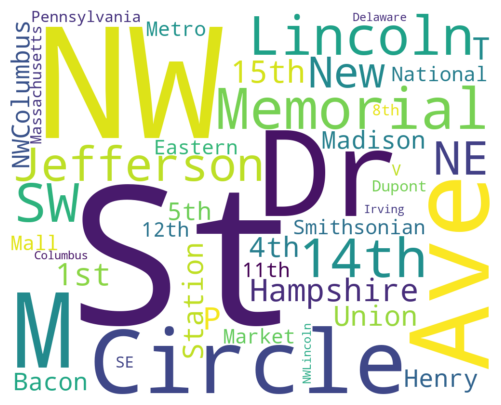

---WORDCLOUD FOR LEAST POPULAR BIKESHARE STATIONS (2020 - 2024)---


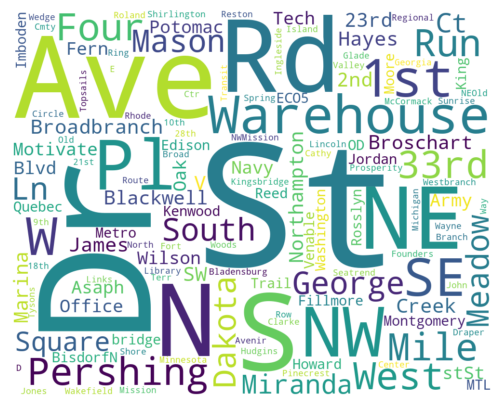

In [19]:
#Create wordcloud of most and least used station names
most_used_stations = ""
least_used_stations = ""


#Loop through 2020 - 2024
for i in range(5):
    #Create strings of station names
    most_used_stations += " ".join(str(element) for element in list(get_bikeshare_station_info(df, (2020 + i)).keys()))
    least_used_stations += " ".join(str(element) for element in list(get_bikeshare_station_info(df, (2020 + i), True).keys()))

#Create word cloud object
wc = WordCloud(
    width = 1000,
    height = 800,
    background_color ='white',
    collocations = False #There are duplicates in the wordcloud without this line
)

#Generate and show wordcloud
print("---WORDCLOUD FOR MOST POPULAR BIKESHARE STATIONS (2020 - 2024)---")
plt.figure(figsize=(8, 5))
plt.imshow(wc.generate(str(most_used_stations)), interpolation='bilinear')
plt.axis("off")
plt.show()

print("---WORDCLOUD FOR LEAST POPULAR BIKESHARE STATIONS (2020 - 2024)---")
plt.figure(figsize=(8, 5))
plt.imshow(wc.generate(str(least_used_stations)), interpolation='bilinear')
plt.axis("off")
plt.show()

The increased density of the least used word map suggests that the least used stations change more often than the most used ones or that they tend to have longer names

Traffic is slowest and calmest on streets
Dr: Slower, Smaller, Calmer road. Often a geographic feature/landmark nearby but not always. 1 - 2 lanes each direction
Ave: Slightly Wider, potentially faster moving traffic. 2 - 3 lanes each direction
DC has few roads, but they are more common in the suburbs